# DVF EDA - Houses Mutations France (2020-2025)
# Author: Xavier VAN AUSLOOS, 14/02/26
# Exploratory Data Analysis on cleaned dataset: df_grouped_2020_2025_france_cleaned.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data & Basic Info

In [2]:
df = pd.read_csv(
    "../data/processed/df_grouped_2020_2025_france_cleaned.csv",
    low_memory=False
)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Shape: (2502263, 42)

Columns (42):
['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Nature mutation', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain', 'mutations']


In [3]:
df.dtypes

Identifiant de document       float64
Reference document            float64
1 Articles CGI                float64
2 Articles CGI                float64
3 Articles CGI                float64
4 Articles CGI                float64
5 Articles CGI                float64
No disposition                  int64
Nature mutation                   str
No voie                       float64
B/T/Q                             str
Type de voie                      str
Code voie                         str
Voie                              str
Code postal                   float64
Commune                           str
Code departement                  str
Code commune                    int64
Prefixe de section            float64
Section                           str
No plan                         int64
No Volume                     float64
1er lot                           str
Surface Carrez du 1er lot         str
2eme lot                          str
Surface Carrez du 2eme lot        str
3eme lot    

In [4]:
df.describe()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,No voie,Code postal,Code commune,Prefixe de section,No plan,No Volume,3eme lot,4eme lot,5eme lot,Nombre de lots,Code type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Surface terrain
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.502263e+06,2.493854e+06,2.502128e+06,2.502263e+06,92976.000000,2.502263e+06,0.0,4463.000000,2298.000000,1306.000000,2.502263e+06,2502263.0,0.0,2.502126e+06,2.502126e+06,2.426747e+06
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.039963e+00,7.117942e+02,4.985702e+04,2.226108e+02,327.509992,4.169741e+02,NaN,31.586825,39.657528,20.934916,2.678495e-02,1.0,NaN,1.014998e+02,4.191344e+00,7.210424e+02
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.871293e-01,1.870872e+03,2.625907e+04,1.749671e+02,261.230722,5.543674e+02,NaN,635.003227,880.487036,79.062706,2.550143e-01,0.0,NaN,4.509721e+01,1.502051e+00,3.890210e+03
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+03,1.000000e+00,1.000000,1.000000e+00,NaN,2.000000,2.000000,2.000000,0.000000e+00,1.0,NaN,1.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,8.000000e+00,2.934000e+04,8.300000e+01,133.000000,9.800000e+01,NaN,4.000000,4.000000,5.000000,0.000000e+00,1.0,NaN,7.400000e+01,3.000000e+00,2.490000e+02
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,2.200000e+01,4.950000e+04,1.850000e+02,251.000000,2.300000e+02,NaN,6.000000,6.000000,6.000000,0.000000e+00,1.0,NaN,9.400000e+01,4.000000e+00,4.950000e+02
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.010000e+02,7.260000e+04,3.180000e+02,466.000000,5.090000e+02,NaN,12.000000,12.000000,13.000000,0.000000e+00,1.0,NaN,1.200000e+02,5.000000e+00,7.810000e+02
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.300000e+02,9.999000e+03,9.749000e+04,9.090000e+02,950.000000,9.914000e+03,NaN,42003.000000,42004.000000,1705.000000,3.800000e+01,1.0,NaN,3.160000e+03,1.980000e+02,3.760000e+06


In [5]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df.sort_values('missing_pct', ascending=False)
print("Missing values (showing columns with any missing):")
missing_df[missing_df['missing_count'] > 0]

Missing values (showing columns with any missing):


,missing_count,missing_pct
Identifiant de document,2502263,100.00
4 Articles CGI,2502263,100.00
Identifiant local,2502263,100.00
Reference document,2502263,100.00
5 Articles CGI,2502263,100.00
No Volume,2502263,100.00
3 Articles CGI,2502263,100.00
2 Articles CGI,2502263,100.00
1 Articles CGI,2502263,100.00
Surface Carrez du 5eme lot,2502117,99.99


In [6]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Nature mutation,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,mutations
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1384.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,140.0,7.0,S,NaN,1347.0,"[{'22/07/2021': '262000,00'}, {'20/05/2022': '260000,00'}]"
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1620.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,2307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,138.0,5.0,J,NaN,510.0,"[{'29/07/2024': '200000,00'}]"
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,20.0,NaN,RUE,1140,DENIS PAPIN,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,74.0,4.0,J,POTAG,755.0,"[{'22/10/2024': '226700,00'}]"
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,12.0,NaN,RUE,1140,DENIS PAPIN,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,81.0,5.0,S,NaN,637.0,"[{'29/09/2021': '240000,00'}]"
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,692.0,NaN,CHE,0330,DES OURES,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,AB,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,167.0,4.0,J,NaN,560.0,"[{'01/07/2024': '249000,00'}]"


## 2. Parse Mutations (prices & dates)

In [7]:
def parse_mutations(mutations_str):
    """Parse mutations string into list of (date, price) tuples."""
    try:
        mutations = ast.literal_eval(mutations_str)
        results = []
        for m in mutations:
            if isinstance(m, dict):
                for date_str, price_str in m.items():
                    date = datetime.strptime(date_str, '%d/%m/%Y')
                    price = float(price_str.replace(',', '.'))
                    results.append((date, price))
        return results
    except:
        return []

df['parsed_mutations'] = df['mutations'].apply(parse_mutations)
df['nb_mutations'] = df['parsed_mutations'].apply(len)

# Extract last mutation price and date for each property
df['last_price'] = df['parsed_mutations'].apply(lambda x: x[-1][1] if x else np.nan)
df['last_date'] = df['parsed_mutations'].apply(lambda x: x[-1][0] if x else pd.NaT)
df['first_price'] = df['parsed_mutations'].apply(lambda x: x[0][1] if x else np.nan)
df['first_date'] = df['parsed_mutations'].apply(lambda x: x[0][0] if x else pd.NaT)

print(f"Properties with parsed mutations: {(df['nb_mutations'] > 0).sum():,}")
print(f"Properties with multiple mutations: {(df['nb_mutations'] > 1).sum():,}")

Properties with parsed mutations: 2,502,263
Properties with multiple mutations: 173,234


## 3. Price Distribution

In [8]:
print("Last mutation price statistics:")
print(df['last_price'].describe())
print(f"\nMedian: {df['last_price'].median():,.0f} €")

Last mutation price statistics:
count    2.498959e+06
mean     3.721018e+05
std      4.648679e+06
min      1.500000e-01
25%      1.208000e+05
50%      2.000000e+05
75%      3.150000e+05
max      7.225900e+08
Name: last_price, dtype: float64

Median: 200,000 €


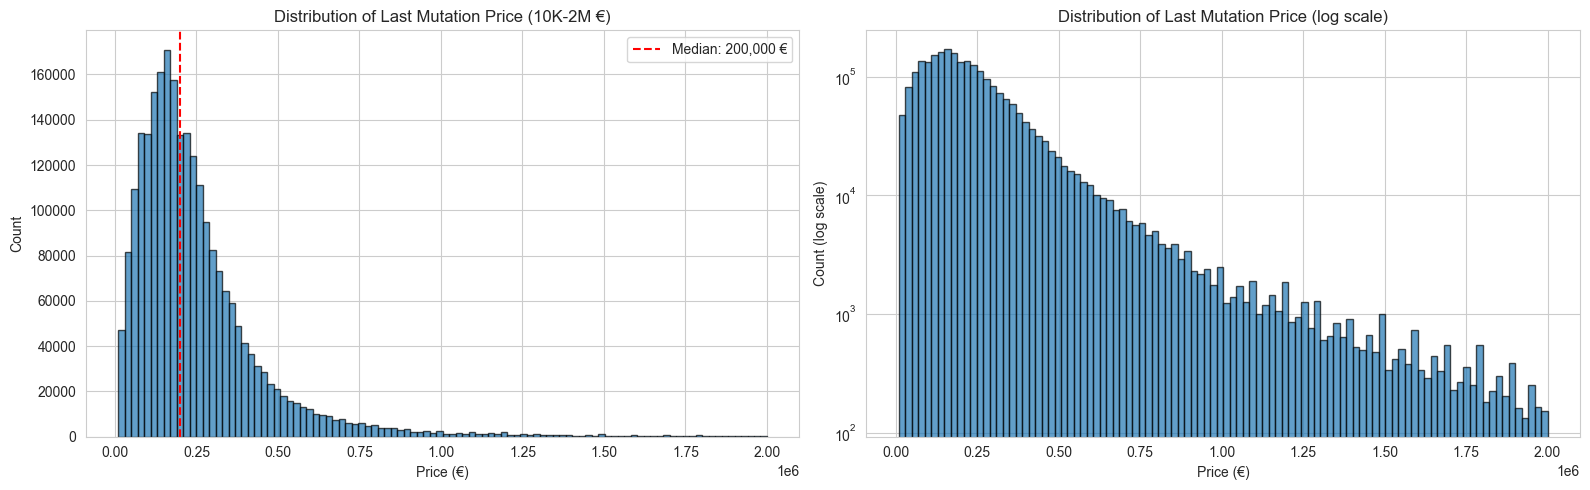

In [9]:
# Price distribution (filter outliers for readability)
price_mask = (df['last_price'] > 10_000) & (df['last_price'] < 2_000_000)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df.loc[price_mask, 'last_price'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Last Mutation Price (10K-2M €)')
axes[0].axvline(df.loc[price_mask, 'last_price'].median(), color='red', linestyle='--', label=f"Median: {df.loc[price_mask, 'last_price'].median():,.0f} €")
axes[0].legend()

axes[1].hist(df.loc[price_mask, 'last_price'], bins=100, edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Price (€)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Last Mutation Price (log scale)')

plt.tight_layout()
plt.show()

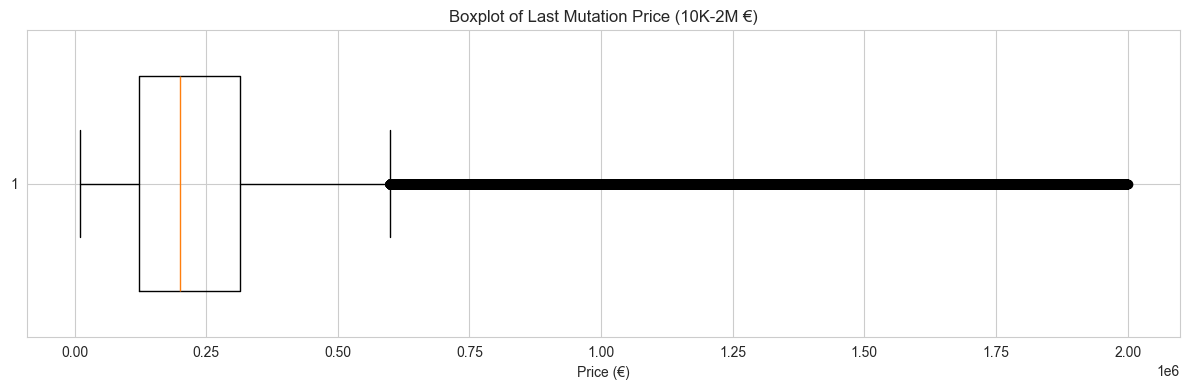

In [10]:
# Boxplot of prices
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(df.loc[price_mask, 'last_price'].dropna(), vert=False, widths=0.7)
ax.set_xlabel('Price (€)')
ax.set_title('Boxplot of Last Mutation Price (10K-2M €)')
plt.tight_layout()
plt.show()

## 4. Geographical Distribution

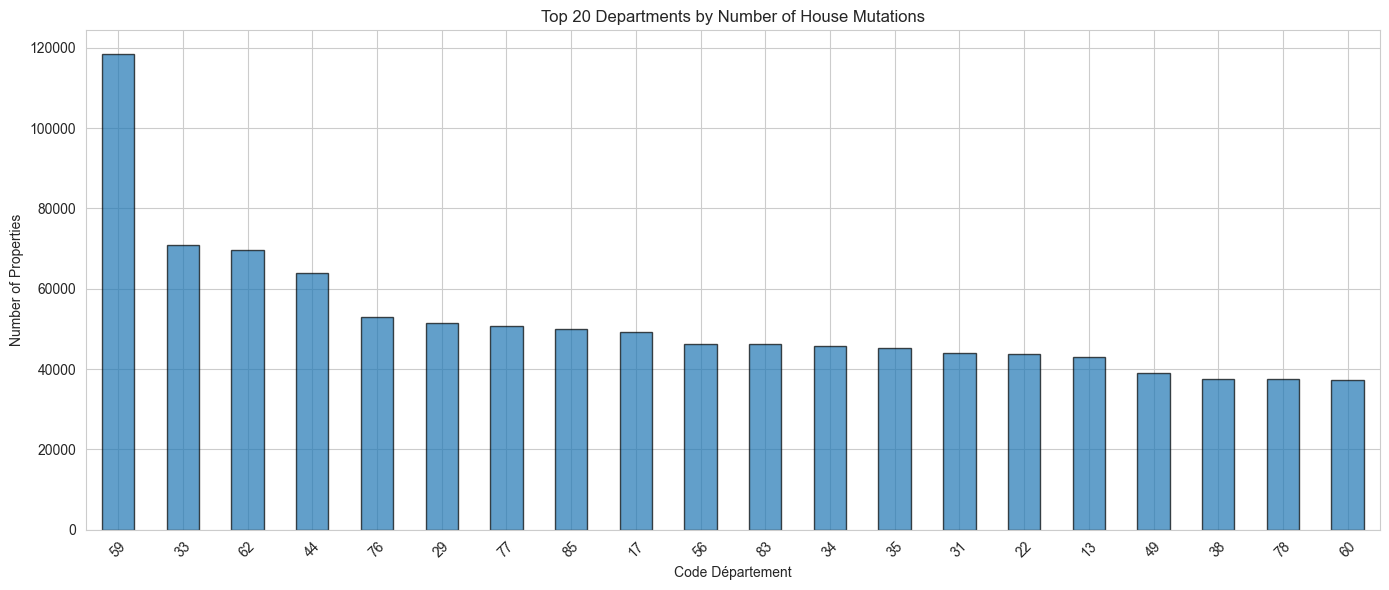

In [11]:
# Top 20 departments by number of properties
dept_counts = df['Code departement'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 6))
dept_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Code Département')
ax.set_ylabel('Number of Properties')
ax.set_title('Top 20 Departments by Number of House Mutations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

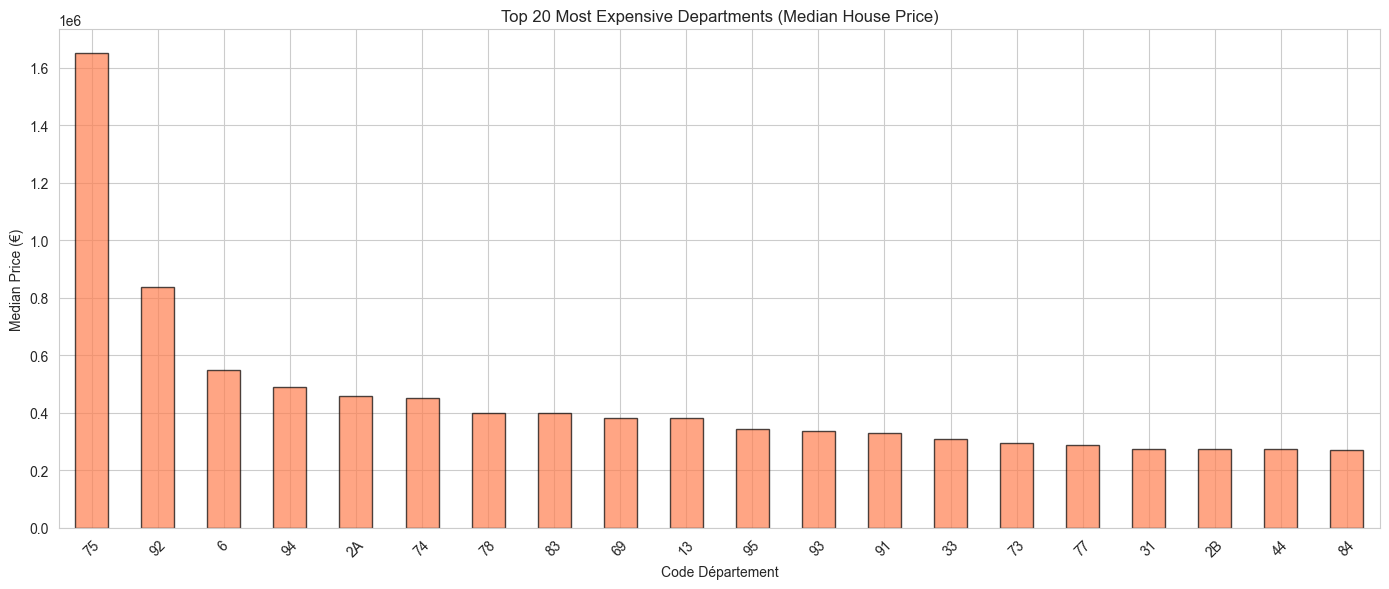

In [12]:
# Median price by department (top 20 most expensive)
dept_median_price = df.groupby('Code departement')['last_price'].median().dropna().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
dept_median_price.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Code Département')
ax.set_ylabel('Median Price (€)')
ax.set_title('Top 20 Most Expensive Departments (Median House Price)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

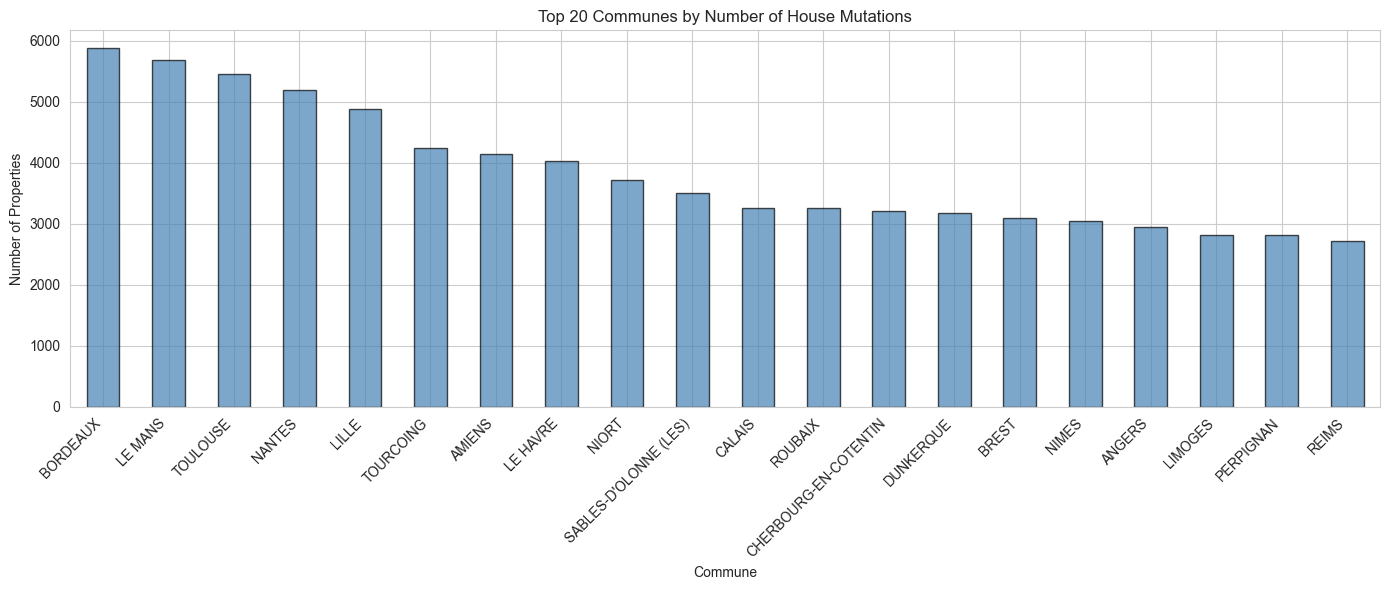

In [13]:
# Top 20 communes by number of mutations
commune_counts = df['Commune'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 6))
commune_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Commune')
ax.set_ylabel('Number of Properties')
ax.set_title('Top 20 Communes by Number of House Mutations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Property Characteristics

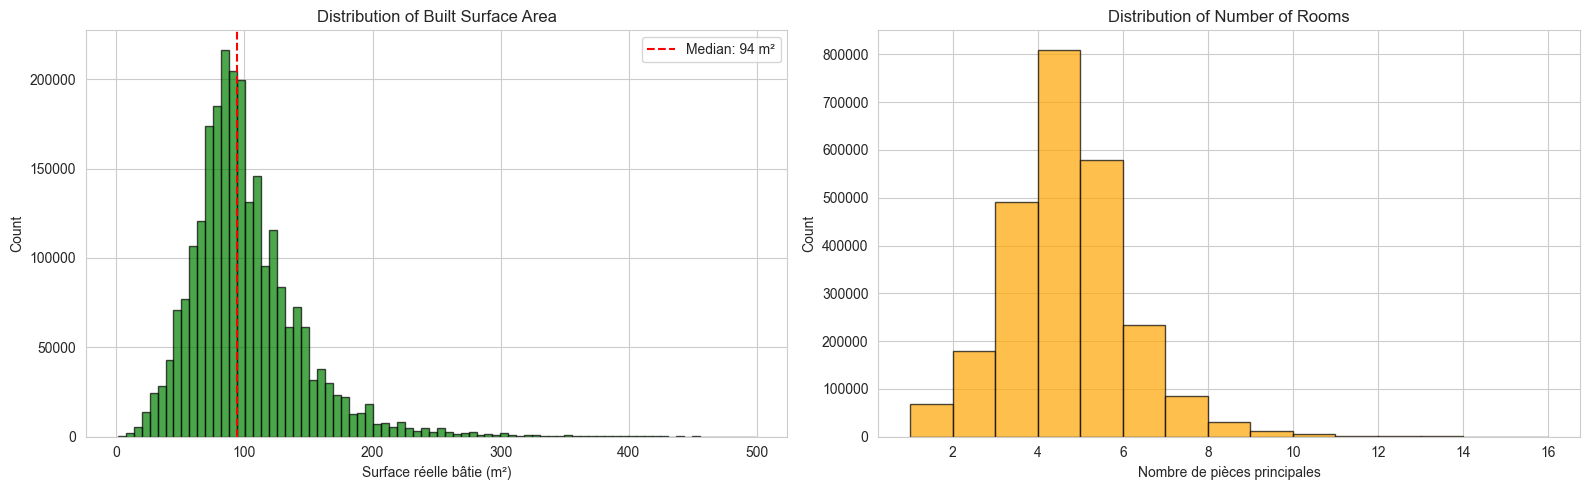

In [14]:
# Surface reelle bati distribution
surface_mask = (df['Surface reelle bati'] > 0) & (df['Surface reelle bati'] < 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df.loc[surface_mask, 'Surface reelle bati'], bins=80, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Surface réelle bâtie (m²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Built Surface Area')
axes[0].axvline(df.loc[surface_mask, 'Surface reelle bati'].median(), color='red', linestyle='--',
               label=f"Median: {df.loc[surface_mask, 'Surface reelle bati'].median():.0f} m²")
axes[0].legend()

# Nombre pieces principales distribution
pieces_mask = (df['Nombre pieces principales'] > 0) & (df['Nombre pieces principales'] <= 15)
axes[1].hist(df.loc[pieces_mask, 'Nombre pieces principales'], bins=range(1, 17), edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Nombre de pièces principales')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Number of Rooms')

plt.tight_layout()
plt.show()

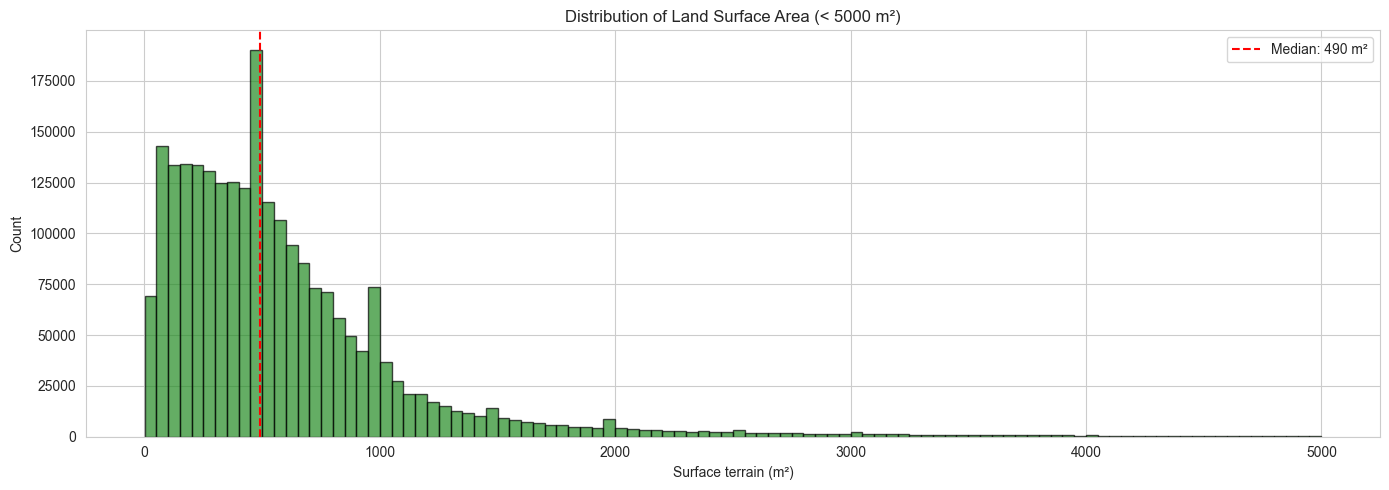

In [15]:
# Surface terrain distribution
terrain_mask = (df['Surface terrain'] > 0) & (df['Surface terrain'] < 5000)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df.loc[terrain_mask, 'Surface terrain'], bins=100, edgecolor='black', alpha=0.7, color='forestgreen')
ax.set_xlabel('Surface terrain (m²)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Land Surface Area (< 5000 m²)')
ax.axvline(df.loc[terrain_mask, 'Surface terrain'].median(), color='red', linestyle='--',
           label=f"Median: {df.loc[terrain_mask, 'Surface terrain'].median():,.0f} m²")
ax.legend()
plt.tight_layout()
plt.show()

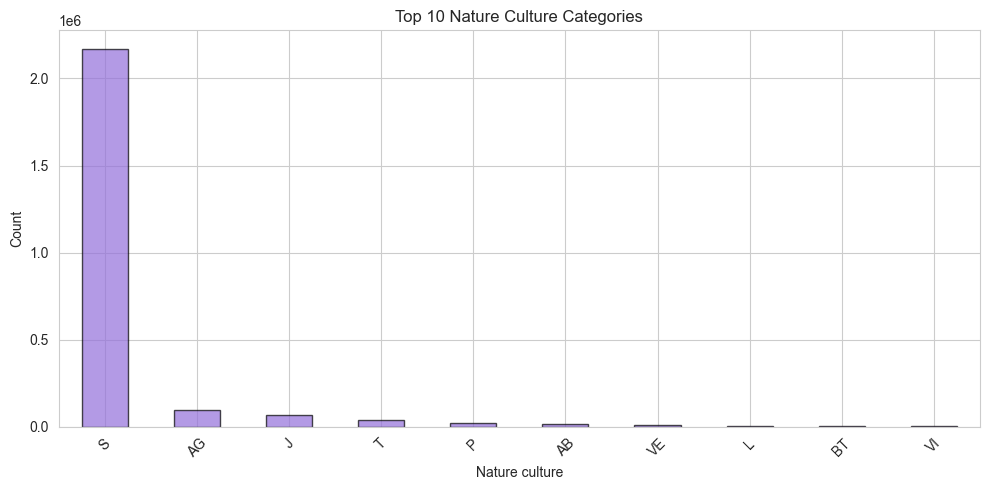

In [16]:
# Nature culture breakdown
nature_culture_counts = df['Nature culture'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
nature_culture_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.set_xlabel('Nature culture')
ax.set_ylabel('Count')
ax.set_title('Top 10 Nature Culture Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Price vs Property Features

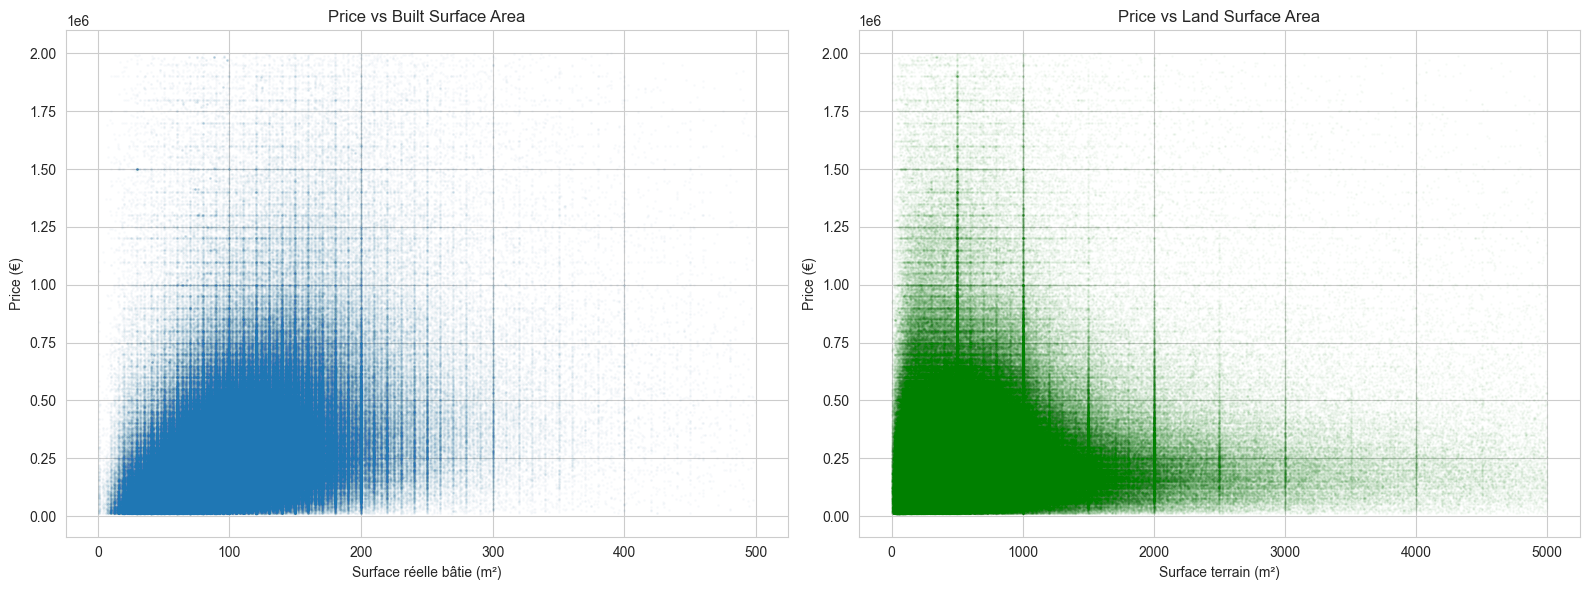

In [17]:
# Price vs Surface reelle bati
scatter_mask = price_mask & surface_mask

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df.loc[scatter_mask, 'Surface reelle bati'], df.loc[scatter_mask, 'last_price'],
               alpha=0.02, s=1)
axes[0].set_xlabel('Surface réelle bâtie (m²)')
axes[0].set_ylabel('Price (€)')
axes[0].set_title('Price vs Built Surface Area')

# Price vs Surface terrain
scatter_mask2 = price_mask & terrain_mask
axes[1].scatter(df.loc[scatter_mask2, 'Surface terrain'], df.loc[scatter_mask2, 'last_price'],
               alpha=0.02, s=1, color='green')
axes[1].set_xlabel('Surface terrain (m²)')
axes[1].set_ylabel('Price (€)')
axes[1].set_title('Price vs Land Surface Area')

plt.tight_layout()
plt.show()

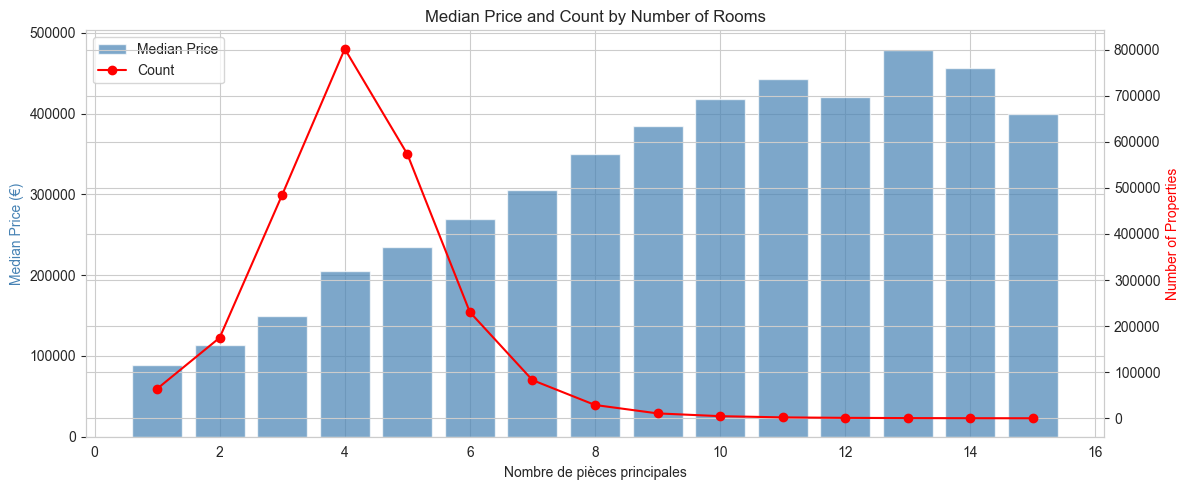

In [18]:
# Median price by number of rooms
price_by_rooms = df[price_mask & pieces_mask].groupby('Nombre pieces principales')['last_price'].agg(['median', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(price_by_rooms.index, price_by_rooms['median'], alpha=0.7, color='steelblue', label='Median Price')
ax2.plot(price_by_rooms.index, price_by_rooms['count'], color='red', marker='o', label='Count')

ax1.set_xlabel('Nombre de pièces principales')
ax1.set_ylabel('Median Price (€)', color='steelblue')
ax2.set_ylabel('Number of Properties', color='red')
ax1.set_title('Median Price and Count by Number of Rooms')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

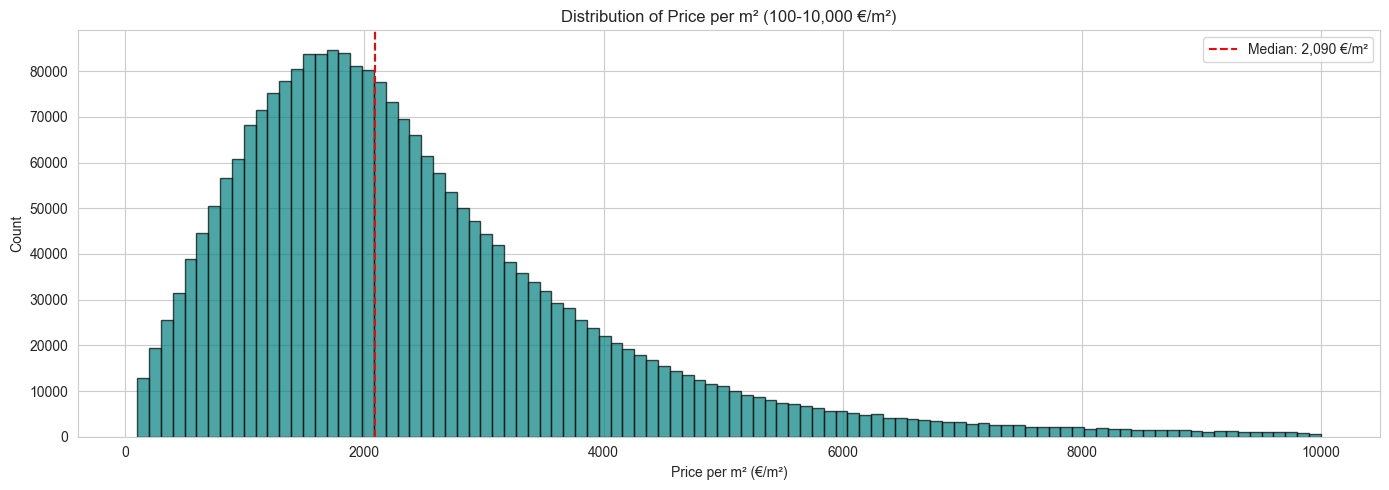

In [19]:
# Price per m² distribution
df['price_per_m2'] = df['last_price'] / df['Surface reelle bati']
ppm2_mask = (df['price_per_m2'] > 100) & (df['price_per_m2'] < 10_000) & df['price_per_m2'].notna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df.loc[ppm2_mask, 'price_per_m2'], bins=100, edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('Price per m² (€/m²)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Price per m² (100-10,000 €/m²)')
ax.axvline(df.loc[ppm2_mask, 'price_per_m2'].median(), color='red', linestyle='--',
           label=f"Median: {df.loc[ppm2_mask, 'price_per_m2'].median():,.0f} €/m²")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Temporal Analysis

In [20]:
# Flatten all mutations to get individual transactions
all_transactions = []
for _, row in df.iterrows():
    for date, price in row['parsed_mutations']:
        all_transactions.append({
            'date': date,
            'price': price,
            'departement': row['Code departement'],
            'commune': row['Commune'],
            'surface_bati': row['Surface reelle bati'],
            'nb_pieces': row['Nombre pieces principales'],
            'surface_terrain': row['Surface terrain']
        })

df_tx = pd.DataFrame(all_transactions)
df_tx['year'] = df_tx['date'].dt.year
df_tx['month'] = df_tx['date'].dt.to_period('M')
df_tx['quarter'] = df_tx['date'].dt.to_period('Q')

print(f"Total individual transactions: {len(df_tx):,}")
df_tx.head()

Total individual transactions: 2,731,059


,date,price,departement,commune,surface_bati,nb_pieces,surface_terrain,year,month,quarter
0,2021-07-22,262000.0,1,SAINT-DENIS-LES-BOURG,140.0,7.0,1347.0,2021,2021-07,2021Q3
1,2022-05-20,260000.0,1,SAINT-DENIS-LES-BOURG,140.0,7.0,1347.0,2022,2022-05,2022Q2
2,2024-07-29,200000.0,1,SAINT-DENIS-LES-BOURG,138.0,5.0,510.0,2024,2024-07,2024Q3
3,2024-10-22,226700.0,1,BOURG-EN-BRESSE,74.0,4.0,755.0,2024,2024-10,2024Q4
4,2021-09-29,240000.0,1,BOURG-EN-BRESSE,81.0,5.0,637.0,2021,2021-09,2021Q3


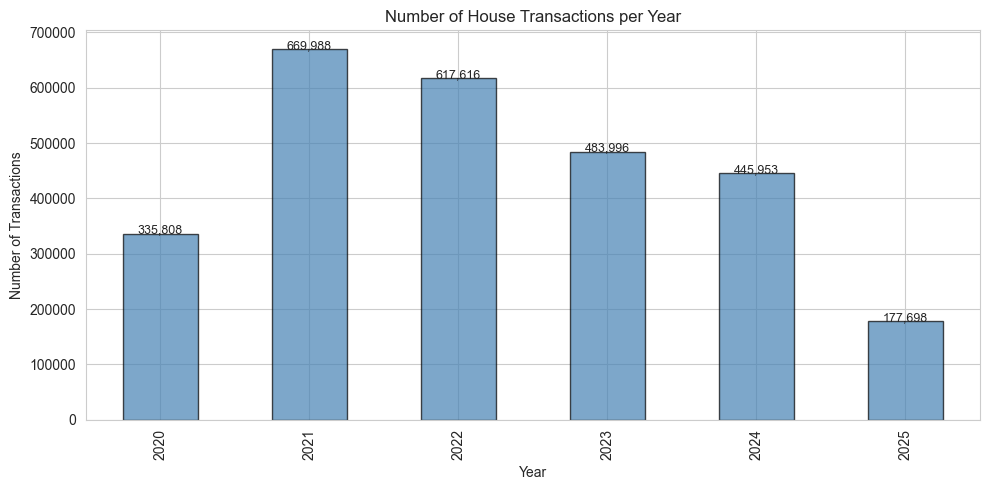

In [21]:
# Number of transactions per year
tx_per_year = df_tx['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
tx_per_year.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Transactions')
ax.set_title('Number of House Transactions per Year')
for i, v in enumerate(tx_per_year.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

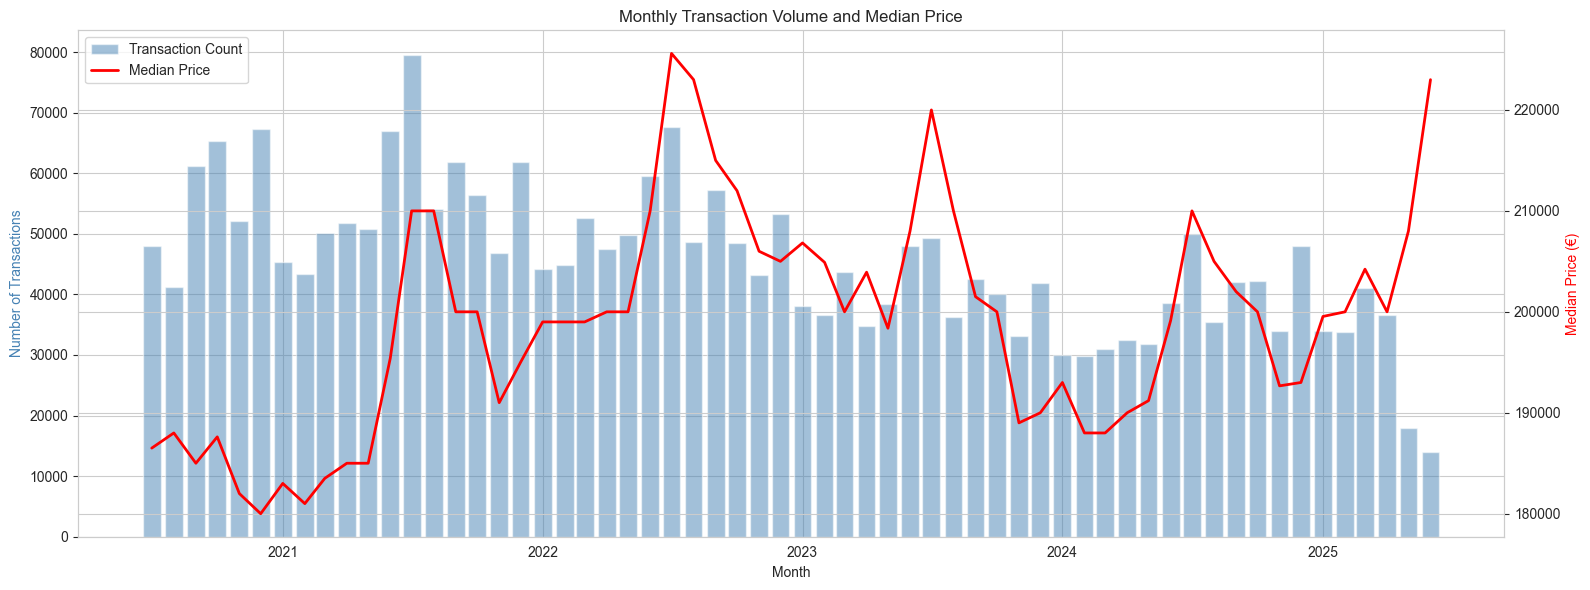

In [22]:
# Monthly transaction volume and median price
monthly = df_tx.groupby('month').agg(
    count=('price', 'count'),
    median_price=('price', 'median')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(monthly['month_dt'], monthly['count'], width=25, alpha=0.5, color='steelblue', label='Transaction Count')
ax2.plot(monthly['month_dt'], monthly['median_price'], color='red', linewidth=2, label='Median Price')

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Transactions', color='steelblue')
ax2.set_ylabel('Median Price (€)', color='red')
ax1.set_title('Monthly Transaction Volume and Median Price')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

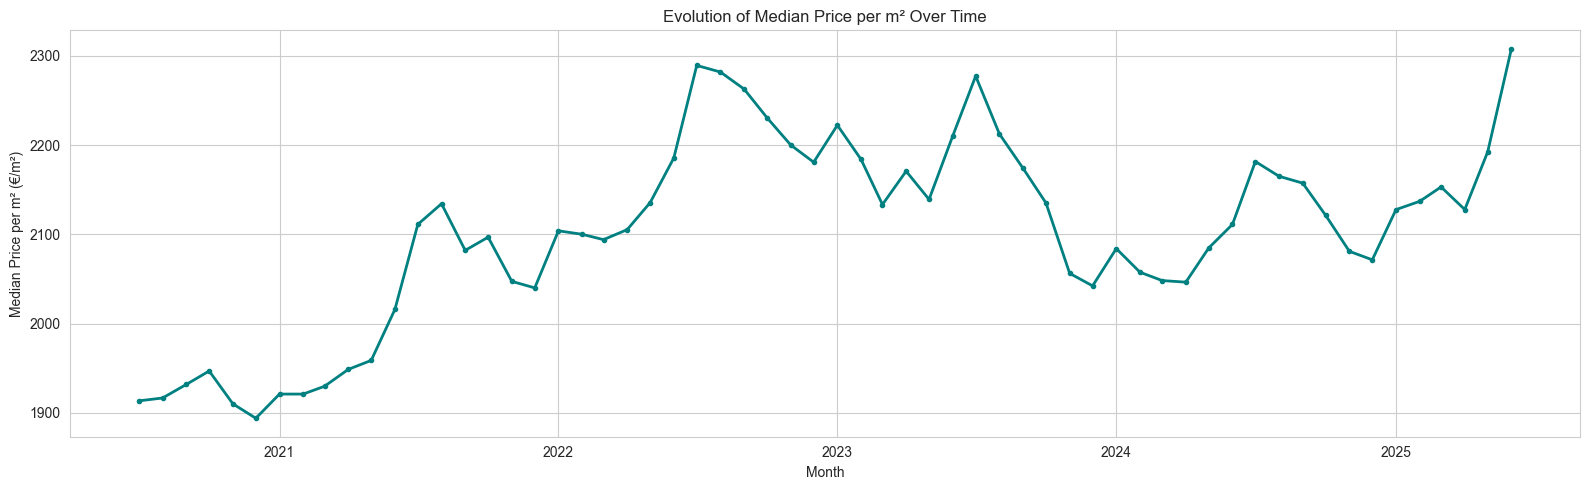

In [23]:
# Median price per m² evolution over time
df_tx['price_per_m2'] = df_tx['price'] / df_tx['surface_bati']
ppm2_tx_mask = (df_tx['price_per_m2'] > 100) & (df_tx['price_per_m2'] < 10_000)

monthly_ppm2 = df_tx[ppm2_tx_mask].groupby('month')['price_per_m2'].median().reset_index()
monthly_ppm2['month_dt'] = monthly_ppm2['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_ppm2['month_dt'], monthly_ppm2['price_per_m2'], color='teal', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Month')
ax.set_ylabel('Median Price per m² (€/m²)')
ax.set_title('Evolution of Median Price per m² Over Time')
plt.tight_layout()
plt.show()

## 8. Repeat Sales Analysis

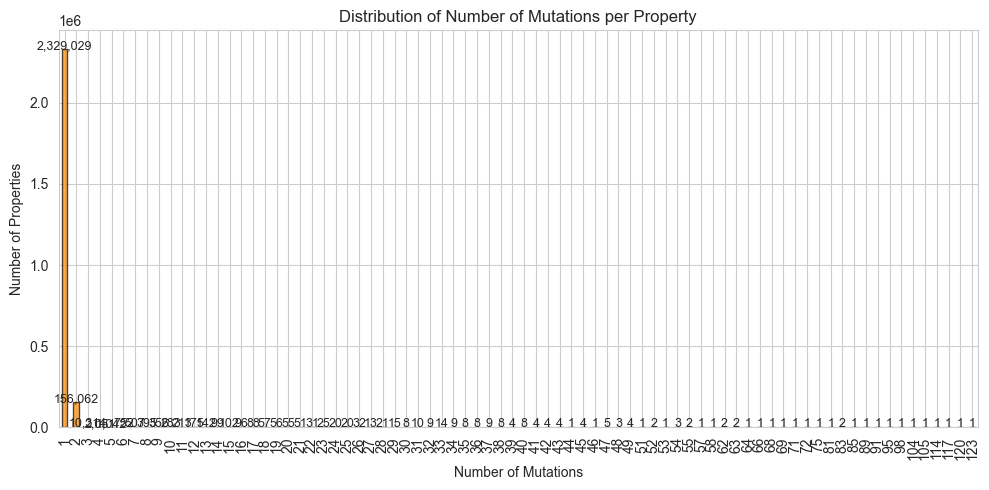

In [24]:
# Distribution of number of mutations per property
mutation_counts = df['nb_mutations'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
mutation_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='darkorange')
ax.set_xlabel('Number of Mutations')
ax.set_ylabel('Number of Properties')
ax.set_title('Distribution of Number of Mutations per Property')
for i, (idx, v) in enumerate(mutation_counts.items()):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# For properties with 2+ mutations: price evolution
multi_mutation = df[df['nb_mutations'] >= 2].copy()
multi_mutation['price_change_pct'] = ((multi_mutation['last_price'] - multi_mutation['first_price']) / multi_mutation['first_price'] * 100)
multi_mutation['holding_days'] = (multi_mutation['last_date'] - multi_mutation['first_date']).dt.days

valid_change = multi_mutation[(multi_mutation['price_change_pct'].between(-80, 200)) & (multi_mutation['holding_days'] > 30)]

print(f"Properties with 2+ mutations: {len(multi_mutation):,}")
print(f"\nPrice change statistics (%):")
print(valid_change['price_change_pct'].describe())
print(f"\nHolding period statistics (days):")
print(valid_change['holding_days'].describe())

Properties with 2+ mutations: 173,234

Price change statistics (%):
count    152387.000000
mean         22.612873
std          48.901364
min         -80.000000
25%          -1.067698
50%          15.094340
75%          40.802299
max         200.000000
Name: price_change_pct, dtype: float64

Holding period statistics (days):
count    152387.000000
mean        758.832059
std         424.274860
min          31.000000
25%         412.000000
50%         723.000000
75%        1078.000000
max        1825.000000
Name: holding_days, dtype: float64


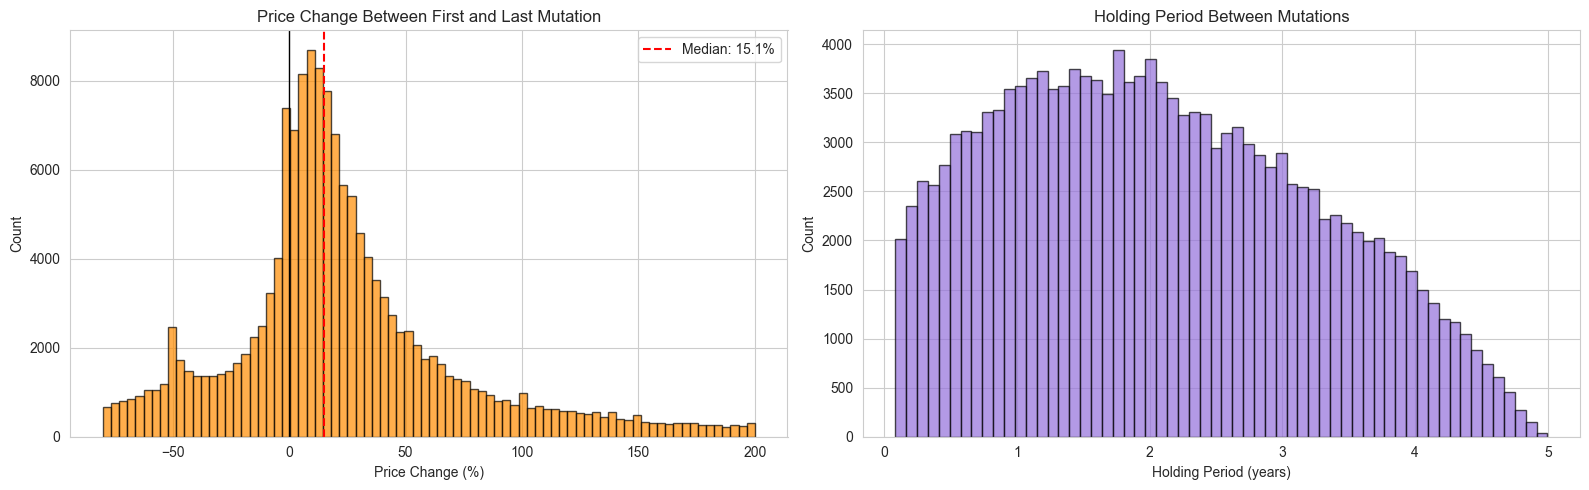

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(valid_change['price_change_pct'], bins=80, edgecolor='black', alpha=0.7, color='darkorange')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].axvline(valid_change['price_change_pct'].median(), color='red', linestyle='--',
               label=f"Median: {valid_change['price_change_pct'].median():.1f}%")
axes[0].set_xlabel('Price Change (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Change Between First and Last Mutation')
axes[0].legend()

axes[1].hist(valid_change['holding_days'] / 365.25, bins=60, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].set_xlabel('Holding Period (years)')
axes[1].set_ylabel('Count')
axes[1].set_title('Holding Period Between Mutations')

plt.tight_layout()
plt.show()

## 9. Correlation Matrix

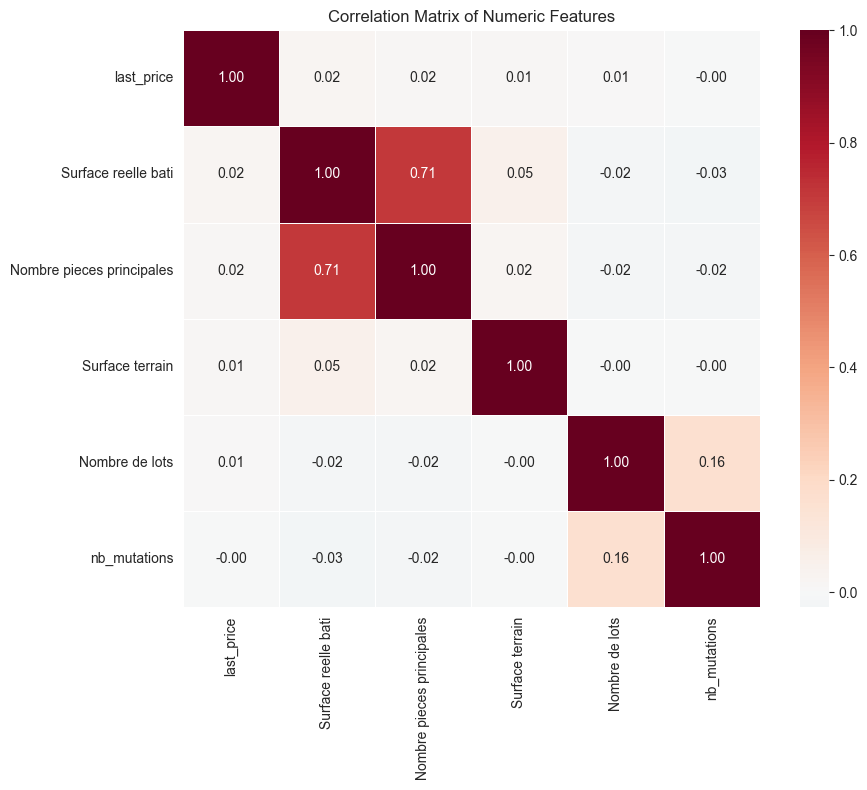

In [27]:
numeric_cols = ['last_price', 'Surface reelle bati', 'Nombre pieces principales',
                'Surface terrain', 'Nombre de lots', 'nb_mutations']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 10. Summary Statistics by Department

In [28]:
dept_summary = df.groupby('Code departement').agg(
    nb_properties=('last_price', 'count'),
    median_price=('last_price', 'median'),
    mean_price=('last_price', 'mean'),
    median_surface=('Surface reelle bati', 'median'),
    median_terrain=('Surface terrain', 'median'),
    median_rooms=('Nombre pieces principales', 'median'),
    median_price_m2=('price_per_m2', 'median')
).round(0).sort_values('median_price', ascending=False)

print("Top 15 departments by median price:")
dept_summary.head(15)

Top 15 departments by median price:


,nb_properties,median_price,mean_price,median_surface,median_terrain,median_rooms,median_price_m2
Code departement,,,,,,,
75,802,1650000.0,3078945.0,118.0,120.0,5.0,15057.0
92,11791,838150.0,1064571.0,102.0,259.0,4.0,8183.0
6,20341,550000.0,1001734.0,105.0,500.0,4.0,5231.0
94,17505,490000.0,618380.0,91.0,327.0,4.0,5488.0
2A,3664,459200.0,717738.0,100.0,925.0,4.0,4586.0
74,22051,451435.0,600029.0,104.0,604.0,4.0,4410.0
78,37439,400000.0,570869.0,102.0,426.0,5.0,3940.0
83,46166,399000.0,642322.0,99.0,500.0,4.0,4057.0
69,31254,383425.0,467822.0,102.0,504.0,4.0,3813.0
